In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text


In [16]:
summary = pd.read_csv("/home/leo/Documentos/mestrado/DeepWeeds-Mobile/results_new/summary_results.csv")
summary

,[Real] Latência Média (ms),[Real] FPS Média,Modelo,Acurácia Média,Precisão Média,Recall Médio,F1 Médio,weighted_precision,weighted_recall,weighted_f1,support_total,Parâmetros (M),GFLOPs,GMAC,Latência Média (ms),FPS Média
0,59.76,16.73,mobilenetv2,0.8812,0.8448,0.8539,0.8461,0.8860,0.8812,0.8818,2626,2.59,0.61,0.31,2.73,366.71
1,74.21,13.47,mobilenetv3large,0.9440,0.9270,0.9266,0.9263,0.9448,0.9440,0.9442,2626,3.24,0.44,0.22,2.66,375.52
2,63.71,15.70,mobilenetv3small,0.8964,0.8837,0.8547,0.8661,0.8974,0.8964,0.8951,2626,1.09,0.12,0.06,2.22,451.43
3,97.86,10.22,resnet50,0.9155,0.8948,0.8848,0.8877,0.9175,0.9155,0.9154,2626,24.11,7.75,3.88,5.98,167.34
4,181.40,5.51,resnet101v2,0.9193,0.8936,0.8933,0.8924,0.9202,0.9193,0.9192,2626,43.15,14.43,7.22,9.46,105.75
5,136.89,7.30,inceptionv3,0.8991,0.8900,0.8544,0.8673,0.9007,0.8991,0.8971,2626,22.33,11.47,5.73,7.74,129.22
6,281.26,3.56,nasnetmobile,0.8679,0.8529,0.8123,0.8232,0.8712,0.8679,0.8643,2626,4.54,1.15,0.57,9.62,104.00
7,140.57,7.11,efficientnetv2b0,0.9181,0.8910,0.8933,0.8911,0.9187,0.9181,0.9178,2626,6.25,1.46,0.73,3.37,296.96
8,172.26,5.81,efficientnetv2b1,0.9250,0.8997,0.9026,0.8990,0.9269,0.9250,0.9248,2626,7.26,2.42,1.21,4.16,240.62
9,178.35,5.61,efficientnetv2b2,0.9334,0.9079,0.9210,0.9133,0.9355,0.9334,0.9337,2626,9.13,3.44,1.72,4.67,214.26


In [33]:
name_map = {
    "nasnetmobile": "NASNetMobile",
    "inceptionv3": "InceptionV3",
    "resnet50": "ResNet-50",
    "resnet101v2": "ResNet-101V2",
    "mobilenetv2": "MobileNetV2",
    "mobilenetv3large": "MobileNetV3-Large",
    "mobilenetv3small": "MobileNetV3-Small",
    "efficientnetv2b0": "EfficientNetV2-B0",
    "efficientnetv2b1": "EfficientNetV2-B1",
    "efficientnetv2b2": "EfficientNetV2-B2",
    "efficientnetv2b3": "EfficientNetV2-B3",
}

summary = summary.copy()
summary["ModelDisplay"] = summary["Modelo"].map(name_map).fillna(summary["Modelo"])

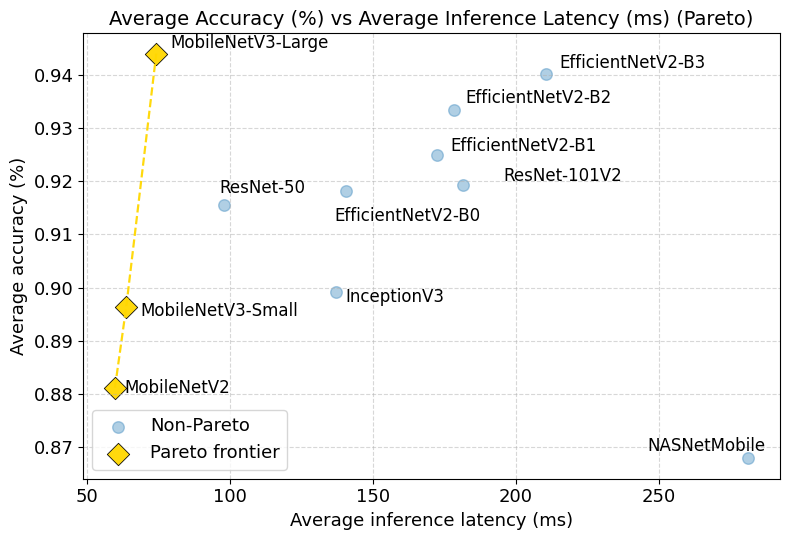

In [37]:
def pareto_frontier_indices_minx_maxy(df, x_col, y_col):
    """
    Retorna índices da fronteira de Pareto para:
      - minimizar x_col (latência)
      - maximizar y_col (acurácia)
    Critério: pontos não-dominados.
    """
    d = df[[x_col, y_col]].dropna().copy()
    d = d.sort_values([x_col, y_col], ascending=[True, False])

    pareto_idx = []
    best_y = -np.inf
    for idx, row in d.iterrows():
        if row[y_col] > best_y:
            pareto_idx.append(idx)
            best_y = row[y_col]
    return pareto_idx


def plot_accuracy_vs_latency_pareto(
    df,
    x_col="[Real] Latência Média (ms)",
    y_col="Acurácia Média",
    label_col="Modelo",
    figsize=(8.0, 5.5),
    font_size=13,
    label_font_size=None,
    marker_size=70,
    pareto_marker_size=130,
    alpha_other=0.35,
    alpha_pareto=0.95,
    annotate_all=True,
    annotate_only_pareto=False,      # se True, anota só Pareto
    grid=True,
    title="Average Accuracy (%) vs Average Inference Latency (ms) (Pareto)",
    x_label="Average inference latency (ms)",
    y_label="Average accuracy (%)",
    x_log=False,
    x_limits=None,
    y_limits=None,
    pareto_line=True,
    save_path=None,
    dpi=300,
    # Ajustes do adjustText
    adjusttext_expand_points=(1.2, 1.2),
    adjusttext_expand_text=(1.2, 1.2),
    adjusttext_force_points=(0.1, 0.2),
    adjusttext_force_text=(0.2, 0.4),
    adjusttext_only_move={"points": "y", "text": "xy"},
    adjusttext_add_arrows=True
):
    # Copia e limpa
    d = df[[x_col, y_col, label_col]].dropna().copy()
    d = d.sort_values([x_col, y_col], ascending=[True, False])

    # Pareto
    pareto_idx = pareto_frontier_indices_minx_maxy(d, x_col, y_col)
    p = d.loc[pareto_idx].sort_values(x_col)

    # Não-Pareto
    d_other = d.drop(index=pareto_idx, errors="ignore")

    fig, ax = plt.subplots(figsize=figsize)

    # Pontos fora do Pareto (azul)
    ax.scatter(
        d_other[x_col], d_other[y_col],
        s=marker_size,
        alpha=alpha_other,
        color="tab:blue",
        label="Non-Pareto"
    )

    # Pontos Pareto (amarelo)
    ax.scatter(
        p[x_col], p[y_col],
        s=pareto_marker_size,
        marker="D",
        alpha=alpha_pareto,
        color="gold",
        edgecolors="black",
        linewidths=0.6,
        label="Pareto frontier"
    )

    # Linha Pareto (amarelo)
    if pareto_line and len(p) >= 2:
        ax.plot(
            p[x_col], p[y_col],
            linestyle="--",
            linewidth=1.6,
            color="gold",
            alpha=0.95
        )

    # Eixos / labels
    ax.set_xlabel(x_label, fontsize=font_size)
    ax.set_ylabel(y_label, fontsize=font_size)
    if title:
        ax.set_title(title, fontsize=font_size + 1)

    # Escala log (opcional)
    if x_log:
        ax.set_xscale("log")

    # Limites (opcional)
    if x_limits is not None:
        ax.set_xlim(*x_limits)
    if y_limits is not None:
        ax.set_ylim(*y_limits)

    # Grid e legenda
    if grid:
        ax.grid(True, linestyle="--", alpha=0.5)

    ax.legend(fontsize=font_size)
    ax.tick_params(labelsize=font_size)

    # --- Anotações com adjustText (evita sobreposição) ---
    fs = label_font_size if label_font_size is not None else (font_size - 1)

    if annotate_only_pareto:
        dd = p
    elif annotate_all:
        dd = d
    else:
        dd = None

    if dd is not None and len(dd) > 0:
        texts = []
        for _, r in dd.iterrows():
            texts.append(
                ax.text(
                    r[x_col], r[y_col], str(r[label_col]),
                    fontsize=fs,
                    clip_on=True
                )
            )

        arrowprops = dict(arrowstyle="-", lw=0.5, alpha=0) if adjusttext_add_arrows else None

        adjust_text(
            texts,
            ax=ax,
            expand_points=adjusttext_expand_points,
            expand_text=adjusttext_expand_text,
            force_points=adjusttext_force_points,
            force_text=adjusttext_force_text,
            only_move=adjusttext_only_move,
            arrowprops=None
        )
    # ----------------------------------------------------

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()


# Exemplo de chamada:
plot_accuracy_vs_latency_pareto(
     summary,
     x_col="[Real] Latência Média (ms)",
     y_col="Acurácia Média",
     label_col="ModelDisplay",
     annotate_all=True,              # ou annotate_only_pareto=True
     font_size=13,
     title="Average Accuracy (%) vs Average Inference Latency (ms) (Pareto)",
     x_label="Average inference latency (ms)",
     y_label="Average accuracy (%)",
     save_path="acc_vs_latency_pareto(final).png"
 )

In [26]:
summary.columns

Index(['[Real] Latência Média (ms)', '[Real] FPS Média', 'Modelo',
       'Acurácia Média', 'Precisão Média', 'Recall Médio', 'F1 Médio',
       'weighted_precision', 'weighted_recall', 'weighted_f1', 'support_total',
       'Parâmetros (M)', 'GFLOPs', 'GMAC', 'Latência Média (ms)', 'FPS Média'],
      dtype='object')

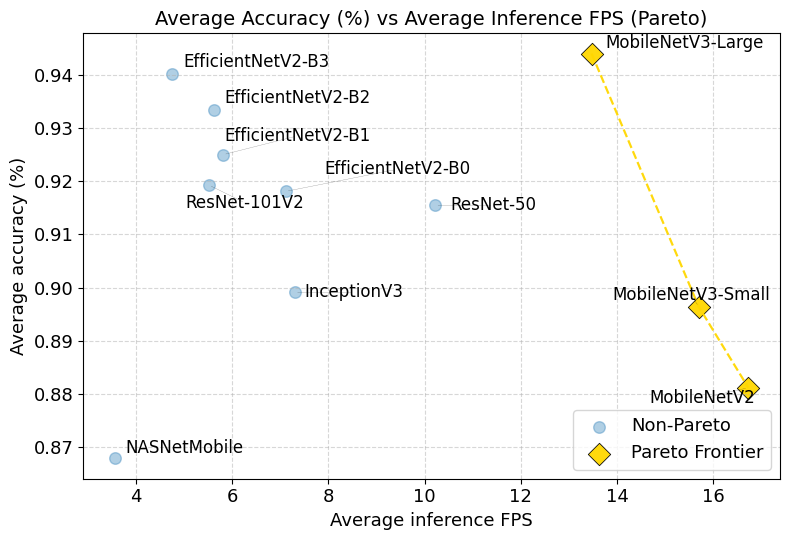

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text


def pareto_frontier_indices_maxx_maxy(df, x_col, y_col):
    """
    Pareto para:
      - maximizar x_col (FPS)
      - maximizar y_col (Acurácia)
    Retorna índices não-dominados (após ordenação por FPS desc, Acc desc).
    """
    d = df[[x_col, y_col]].dropna().copy()
    d = d.sort_values([x_col, y_col], ascending=[False, False])

    pareto_idx = []
    best_y = -np.inf
    for idx, row in d.iterrows():
        if row[y_col] > best_y:
            pareto_idx.append(idx)
            best_y = row[y_col]
    return pareto_idx


def plot_accuracy_vs_fps_pareto(
    df,
    x_col="[Real] FPS Média",
    y_col="Acurácia Média",
    label_col="ModelDisplay",
    figsize=(8.0, 5.5),
    font_size=13,
    label_font_size=None,
    marker_size=70,
    pareto_marker_size=130,
    alpha_other=0.35,
    alpha_pareto=0.95,
    annotate_all=True,
    annotate_only_pareto=False,
    grid=True,
    title="Average Accuracy (%) vs Average Inference FPS (Pareto)",
    x_label="Average inference FPS",
    y_label="Average accuracy (%)",
    x_log=False,
    x_limits=None,
    y_limits=None,
    pareto_line=True,
    save_path=None,
    dpi=300,
    # adjustText (sem linhas)
    adjusttext_expand_points=(1.2, 1.2),
    adjusttext_expand_text=(1.2, 1.2),
    adjusttext_force_points=(0.1, 0.2),
    adjusttext_force_text=(0.2, 0.4),
    adjusttext_only_move={"points": "y", "text": "xy"},
):
    # Copia e limpa
    d = df[[x_col, y_col, label_col]].dropna().copy()
    d = d.sort_values([x_col, y_col], ascending=[False, False])

    # Pareto (max FPS, max Acc)
    pareto_idx = pareto_frontier_indices_maxx_maxy(d, x_col, y_col)
    p = d.loc[pareto_idx].sort_values(x_col)  # ordenar para desenhar linha

    # Não-Pareto
    d_other = d.drop(index=pareto_idx, errors="ignore")

    fig, ax = plt.subplots(figsize=figsize)

    # Pontos fora do Pareto (azul)
    ax.scatter(
        d_other[x_col], d_other[y_col],
        s=marker_size,
        alpha=alpha_other,
        color="tab:blue",
        label="Non-Pareto"
    )

    # Pontos Pareto (amarelo)
    ax.scatter(
        p[x_col], p[y_col],
        s=pareto_marker_size,
        marker="D",
        alpha=alpha_pareto,
        color="gold",
        edgecolors="black",
        linewidths=0.6,
        label="Pareto Frontier"
    )

    # Linha Pareto (amarelo)
    if pareto_line and len(p) >= 2:
        ax.plot(
            p[x_col], p[y_col],
            linestyle="--",
            linewidth=1.6,
            color="gold",
            alpha=0.95
        )

    # Labels
    ax.set_xlabel(x_label, fontsize=font_size)
    ax.set_ylabel(y_label, fontsize=font_size)
    if title:
        ax.set_title(title, fontsize=font_size + 1)

    if x_log:
        ax.set_xscale("log")

    if x_limits is not None:
        ax.set_xlim(*x_limits)
    if y_limits is not None:
        ax.set_ylim(*y_limits)

    if grid:
        ax.grid(True, linestyle="--", alpha=0.5)

    ax.legend(fontsize=font_size)
    ax.tick_params(labelsize=font_size)

    # Anotações (adjustText sem linhas)
    fs = label_font_size if label_font_size is not None else (font_size - 1)
    adjusttext_add_arrows=True
    arrowprops = dict(arrowstyle="-", lw=0.2, alpha=.5) if adjusttext_add_arrows else None

    if annotate_only_pareto:
        dd = p
    elif annotate_all:
        dd = d
    else:
        dd = None

    if dd is not None and len(dd) > 0:
        texts = [
            ax.text(r[x_col], r[y_col], str(r[label_col]), fontsize=fs, clip_on=True)
            for _, r in dd.iterrows()
        ]

        adjust_text(
            texts,
            ax=ax,
            expand_points=adjusttext_expand_points,
            expand_text=adjusttext_expand_text,
            force_points=adjusttext_force_points,
            force_text=adjusttext_force_text,
            only_move=adjusttext_only_move,
            arrowprops=arrowprops  # remove linhas
        )

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()


# Exemplo:
plot_accuracy_vs_fps_pareto(
     summary,
     x_col="[Real] FPS Média",
     y_col="Acurácia Média",
     label_col="ModelDisplay",
     annotate_all=True,
     save_path="acc_vs_FPS_pareto(final).png"
 )


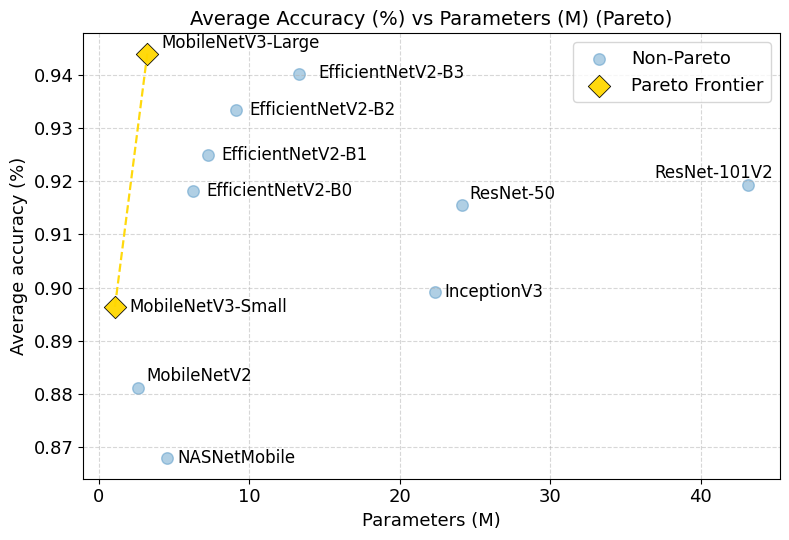

In [54]:
def pareto_frontier_indices_minx_maxy(df, x_col, y_col):
    """
    Pareto para:
      - minimizar x_col (Parâmetros)
      - maximizar y_col (Acurácia)
    Retorna índices não-dominados.
    """
    d = df[[x_col, y_col]].dropna().copy()
    d = d.sort_values([x_col, y_col], ascending=[True, False])

    pareto_idx = []
    best_y = -np.inf
    for idx, row in d.iterrows():
        if row[y_col] > best_y:
            pareto_idx.append(idx)
            best_y = row[y_col]
    return pareto_idx


def plot_accuracy_vs_params_pareto(
    df,
    x_col="Parâmetros (M)",
    y_col="Acurácia Média",
    label_col="Modelo",                 # use "ModelDisplay" se criou a coluna bonitinha
    figsize=(8.0, 5.5),
    font_size=13,
    label_font_size=None,
    marker_size=70,
    pareto_marker_size=130,
    alpha_other=0.35,
    alpha_pareto=0.95,
    annotate_all=True,
    annotate_only_pareto=False,
    grid=True,
    title="Average Accuracy (%) vs Parameters (M) (Pareto)",
    x_label="Parameters (M)",
    y_label="Average accuracy (%)",
    x_log=False,                        # útil se houver muita diferença de escala
    x_limits=None,
    y_limits=None,
    pareto_line=True,
    save_path=None,
    dpi=300,
    # adjustText (sem linhas)
    adjusttext_expand_points=(1.2, 1.2),
    adjusttext_expand_text=(1.2, 1.2),
    adjusttext_force_points=(0.1, 0.2),
    adjusttext_force_text=(0.2, 0.4),
    adjusttext_only_move={"points": "y", "text": "xy"},
):
    # Copia e limpa
    d = df[[x_col, y_col, label_col]].dropna().copy()
    d = d.sort_values([x_col, y_col], ascending=[True, False])

    # Pareto (min params, max acc)
    pareto_idx = pareto_frontier_indices_minx_maxy(d, x_col, y_col)
    p = d.loc[pareto_idx].sort_values(x_col)

    # Não-Pareto
    d_other = d.drop(index=pareto_idx, errors="ignore")

    fig, ax = plt.subplots(figsize=figsize)

    # Pontos fora do Pareto (azul)
    ax.scatter(
        d_other[x_col], d_other[y_col],
        s=marker_size,
        alpha=alpha_other,
        color="tab:blue",
        label="Non-Pareto"
    )

    # Pontos Pareto (amarelo)
    ax.scatter(
        p[x_col], p[y_col],
        s=pareto_marker_size,
        marker="D",
        alpha=alpha_pareto,
        color="gold",
        edgecolors="black",
        linewidths=0.6,
        label="Pareto Frontier"
    )

    # Linha Pareto (amarelo)
    if pareto_line and len(p) >= 2:
        ax.plot(
            p[x_col], p[y_col],
            linestyle="--",
            linewidth=1.6,
            color="gold",
            alpha=0.95
        )

    # Labels
    ax.set_xlabel(x_label, fontsize=font_size)
    ax.set_ylabel(y_label, fontsize=font_size)
    if title:
        ax.set_title(title, fontsize=font_size + 1)

    if x_log:
        ax.set_xscale("log")

    if x_limits is not None:
        ax.set_xlim(*x_limits)
    if y_limits is not None:
        ax.set_ylim(*y_limits)

    if grid:
        ax.grid(True, linestyle="--", alpha=0.5)

    ax.legend(fontsize=font_size)
    ax.tick_params(labelsize=font_size)

    # Anotações (adjustText sem linhas)
    fs = label_font_size if label_font_size is not None else (font_size - 1)

    if annotate_only_pareto:
        dd = p
    elif annotate_all:
        dd = d
    else:
        dd = None

    if dd is not None and len(dd) > 0:
        texts = [
            ax.text(r[x_col], r[y_col], str(r[label_col]), fontsize=fs, clip_on=True)
            for _, r in dd.iterrows()
        ]

        adjust_text(
            texts,
            ax=ax,
            expand_points=adjusttext_expand_points,
            expand_text=adjusttext_expand_text,
            force_points=adjusttext_force_points,
            force_text=adjusttext_force_text,
            only_move=adjusttext_only_move,
            arrowprops=None
        )

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()


# Exemplo:
plot_accuracy_vs_params_pareto(
     summary,
     x_col="Parâmetros (M)",
     y_col="Acurácia Média",
     label_col="ModelDisplay",  # se você criou a coluna com nomes bonitos
     annotate_all=True,
     x_log=False   ,
    
     save_path="acc_vs_parameters_pareto(final).png"
 )

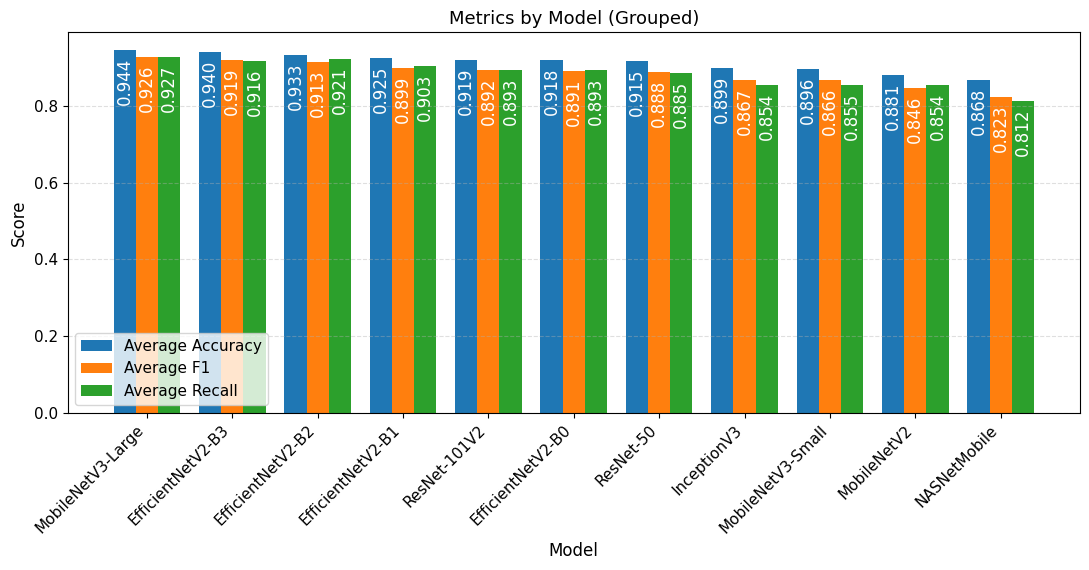

In [104]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

def plot_metrics_by_model_grouped(
    df,
    model_col="ModelDisplay",
    acc_col="Acurácia Média",
    f1_col="F1 Médio",
    rec_col="Recall Médio",
    figsize=(11, 5.8),
    font_size=12,
    bar_width=0.26,
    value_fmt="{:.3f}",
    rotate_xticks=45
):
    # Seleciona e ordena pelo maior Accuracy
    d = df[[model_col, acc_col, f1_col, rec_col]].dropna().copy()
    d = d.sort_values(acc_col, ascending=False).reset_index(drop=True)

    models = d[model_col].astype(str).tolist()
    acc = d[acc_col].to_numpy()
    f1 = d[f1_col].to_numpy()
    rec = d[rec_col].to_numpy()

    x = np.arange(len(models))

    fig, ax = plt.subplots(figsize=figsize)

    b1 = ax.bar(x - bar_width, acc, width=bar_width, label="Average Accuracy")
    b2 = ax.bar(x,            f1,  width=bar_width, label="Average F1")
    b3 = ax.bar(x + bar_width, rec, width=bar_width, label="Average Recall")

    # Valores dentro da barra (vertical, branco)
    def add_labels_inside(bars):
        for bar in bars:
            h = bar.get_height()
            # posição: um pouco abaixo do topo para ficar "dentro"
            y = h - 0.02  # ajuste fino; se seus valores forem próximos de 1, funciona bem
            if y < 0:     # segurança
                y = h * 0.5

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y,
                value_fmt.format(h),
                ha="center",
                va="top",
                rotation=90,
                fontsize=font_size ,
                color="white",
                clip_on=True
            )

    add_labels_inside(b1)
    add_labels_inside(b2)
    add_labels_inside(b3)

    ax.set_title("Metrics by Model (Grouped)", fontsize=font_size + 1)
    ax.set_xlabel("Model", fontsize=font_size)
    ax.set_ylabel("Score", fontsize=font_size)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=rotate_xticks, ha="right", fontsize=font_size - 1)
    ax.tick_params(axis="y", labelsize=font_size - 1)

    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    ax.legend(fontsize=font_size - 1)

    plt.tight_layout()
    
    plt.savefig("metrics_by_model(final).png", dpi=300, bbox_inches="tight")
    plt.show()


# Exemplo:
plot_metrics_by_model_grouped(summary)

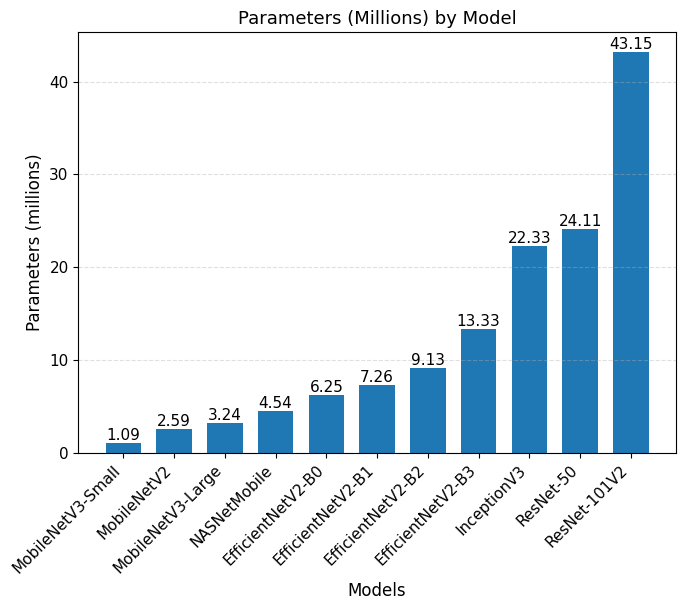

In [105]:
def plot_parameters_by_model(
    df,
    model_col="Modelo",
    params_col="Parâmetros (M)",
    figsize=(7.0, 6.2),          
    font_size=12,
    value_fmt="{:.2f}",
    rotate_xticks=45,
    bar_width=0.7              # barras mais finas (padrão ~0.8)
):
    d = df[[model_col, params_col]].dropna().copy()
    d = d.sort_values(params_col, ascending=True).reset_index(drop=True)

    models = d[model_col].astype(str).tolist()
    params = d[params_col].to_numpy()
    x = np.arange(len(models))

    fig, ax = plt.subplots(figsize=figsize)

    bars = ax.bar(x, params, width=bar_width)

    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h,
            value_fmt.format(h),
            ha="center",
            va="bottom",
            fontsize=font_size - 1,
            clip_on=True
        )

    ax.set_title("Parameters (Millions) by Model", fontsize=font_size + 1)
    ax.set_xlabel("Models", fontsize=font_size)
    ax.set_ylabel("Parameters (millions)", fontsize=font_size)

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=rotate_xticks, ha="right", fontsize=font_size - 1)
    ax.tick_params(axis="y", labelsize=font_size - 1)

    ax.grid(True, axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    
    plt.savefig("parameters_by_model(final).png", dpi=300, bbox_inches="tight")
    plt.show()


plot_parameters_by_model(summary, model_col="ModelDisplay")

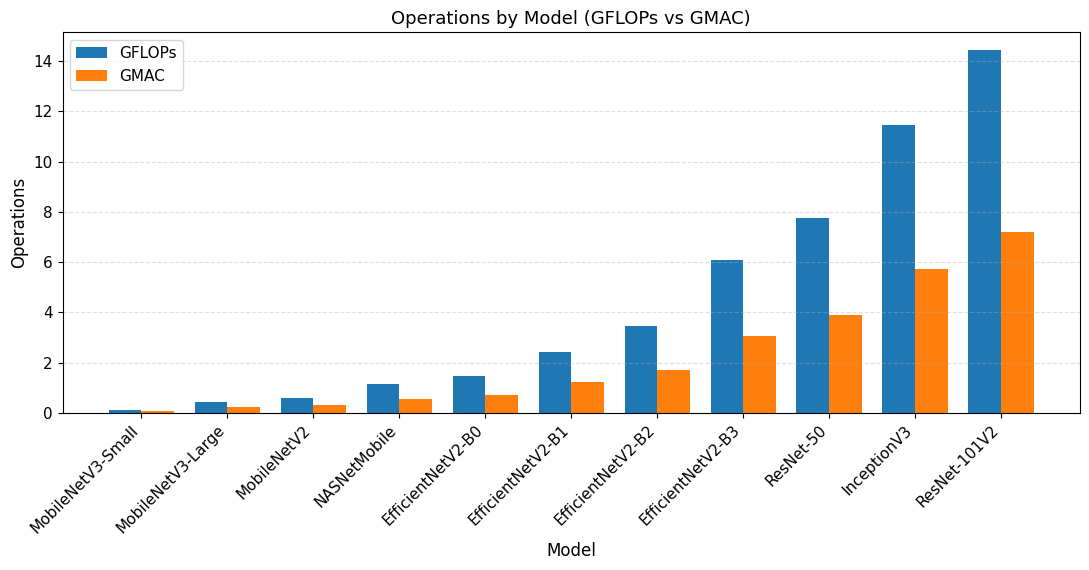

In [74]:
import numpy as np
import matplotlib.pyplot as plt


def plot_operations_by_model_grouped(
    df,
    model_col="Modelo",
    gflops_col="GFLOPs",
    gmac_col="GMAC",
    figsize=(11.0, 5.8),
    font_size=12,
    bar_width=0.38,          # largura de cada barra
    rotate_xticks=45,
    sort_by="GFLOPs"         # "GFLOPs" ou "GMAC"
):
    d = df[[model_col, gflops_col, gmac_col]].dropna().copy()
    if sort_by == "GMAC":
        d = d.sort_values(gmac_col, ascending=True).reset_index(drop=True)
    else:
        d = d.sort_values(gflops_col, ascending=True).reset_index(drop=True)

    models = d[model_col].astype(str).tolist()
    gflops = d[gflops_col].to_numpy()
    gmac = d[gmac_col].to_numpy()

    x = np.arange(len(models))

    fig, ax = plt.subplots(figsize=figsize)

    # “Coladas”: centers separados exatamente por bar_width
    offset = bar_width / 2

    ax.bar(x - offset, gflops, width=bar_width, label="GFLOPs")
    ax.bar(x + offset, gmac,   width=bar_width, label="GMAC")

    ax.set_title("Operations by Model (GFLOPs vs GMAC)", fontsize=font_size + 1)
    ax.set_xlabel("Model", fontsize=font_size)
    ax.set_ylabel("Operations", fontsize=font_size)

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=rotate_xticks, ha="right", fontsize=font_size - 1)
    ax.tick_params(axis="y", labelsize=font_size - 1)

    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    ax.legend(fontsize=font_size - 1)

    plt.tight_layout()
    plt.show()


# Exemplo:
plot_operations_by_model_grouped(summary, model_col="ModelDisplay")

In [93]:
import re
results = pd.read_csv("/home/leo/Documentos/mestrado/DeepWeeds-Mobile/results_new/results_byclass.csv")
raw = results.copy()

def prettify_model_name(s: str) -> str:
    s = str(s).strip().lower()

    exceptions = {
        "nasnetmobile": "NASNetMobile",
        "inceptionv3": "InceptionV3",
        "resnet50": "ResNet-50",
        "resnet101v2": "ResNet-101V2",
        "mobilenetv2": "MobileNetV2",
        "mobilenetv3large": "MobileNetV3-Large",
        "mobilenetv3small": "MobileNetV3-Small",
    }
    if s in exceptions:
        return exceptions[s]

    m = re.match(r"efficientnetv2b(\d+)$", s)
    if m:
        return f"EfficientNetV2-B{m.group(1)}"

    # fallback
    return s[:1].upper() + s[1:]




if "Unnamed: 0" in raw.columns:
    raw = raw.rename(columns={"Unnamed: 0": "row_name"})

# remove as duas primeiras linhas (class/model) e fica só com modelos
d = raw.iloc[2:].copy()
d = d.rename(columns={"row_name": "model"}).reset_index(drop=True)

# transforma wide -> long
long = d.melt(id_vars=["model"], var_name="col", value_name="value")
long["value"] = pd.to_numeric(long["value"], errors="coerce")

# parse: metric e class_id a partir do padrão: f1, f1.1, ..., recall.8
m = long["col"].str.extract(r"^(f1|precision|recall)(?:\.(\d+))?$")
long["metric"] = m[0]
long["class"] = m[1].fillna("0").astype(int)

# mantém só o que é métrica válida
long = long.dropna(subset=["metric", "value"]).drop(columns=["col"])
long["ModelDisplay"] = long["model"].apply(prettify_model_name)

long

,model,value,metric,class,ModelDisplay
0,efficientnetv2b0,0.8624,f1,0,EfficientNetV2-B0
1,efficientnetv2b1,0.8630,f1,0,EfficientNetV2-B1
2,efficientnetv2b2,0.8701,f1,0,EfficientNetV2-B2
3,efficientnetv2b3,0.8793,f1,0,EfficientNetV2-B3
4,inceptionv3,0.8263,f1,0,InceptionV3
...,...,...,...,...,...
292,mobilenetv3large,0.9649,recall,8,MobileNetV3-Large
293,mobilenetv3small,0.9451,recall,8,MobileNetV3-Small
294,nasnetmobile,0.9327,recall,8,NASNetMobile
295,resnet101v2,0.9502,recall,8,ResNet-101V2


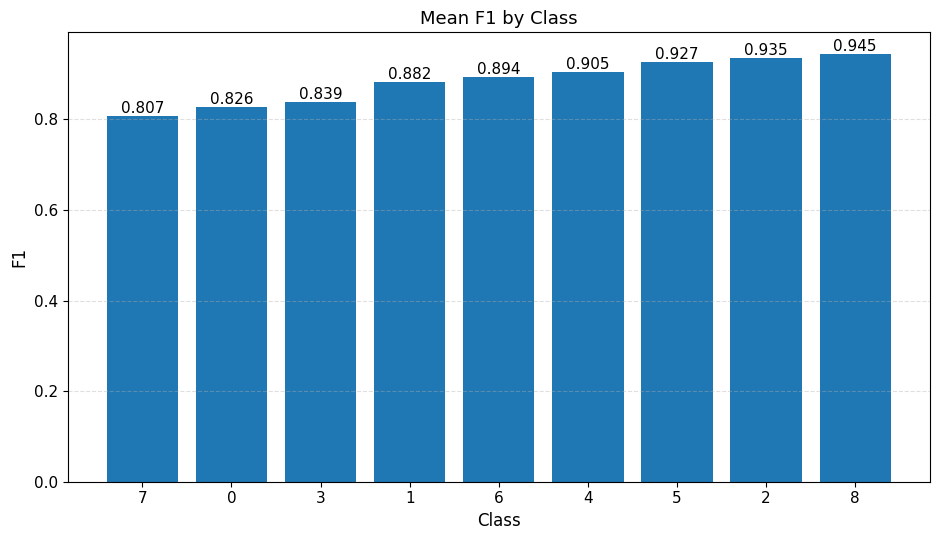

In [106]:
def plot_mean_f1_by_class(
    df_long,
    class_col="class",
    value_col="value",
    metric_col="metric",
    metric_name="f1",
    figsize=(9.5, 5.5),
    font_size=12,
    value_fmt="{:.3f}",
    show_values=True,
    order="desc",          # "desc" (maior->menor) ou "asc" ou "class"
):
    d = df_long[df_long[metric_col] == metric_name].copy()

    # média por classe
    agg = (
        d.groupby(class_col, as_index=False)[value_col]
        .mean()
        .rename(columns={value_col: "mean_f1"})
    )

    if order == "desc":
        agg = agg.sort_values("mean_f1", ascending=False)
    elif order == "asc":
        agg = agg.sort_values("mean_f1", ascending=True)
    else:  # "class"
        agg = agg.sort_values(class_col, ascending=True)

    x_labels = agg[class_col].astype(str).tolist()
    y = agg["mean_f1"].to_numpy()
    x = np.arange(len(x_labels))

    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(x, y)

    if show_values:
        for bar in bars:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h,
                value_fmt.format(h),
                ha="center",
                va="bottom",
                fontsize=font_size - 1,
                clip_on=True
            )

    ax.set_title("Mean F1 by Class", fontsize=font_size + 1)
    ax.set_xlabel("Class", fontsize=font_size)
    ax.set_ylabel("F1", fontsize=font_size)

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=font_size - 1)
    ax.tick_params(axis="y", labelsize=font_size - 1)

    ax.grid(True, axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    
    plt.savefig("f1score_byclass(final).png", dpi=300, bbox_inches="tight")
    plt.show() 


plot_mean_f1_by_class(long, order="asc")  # ou order="desc"

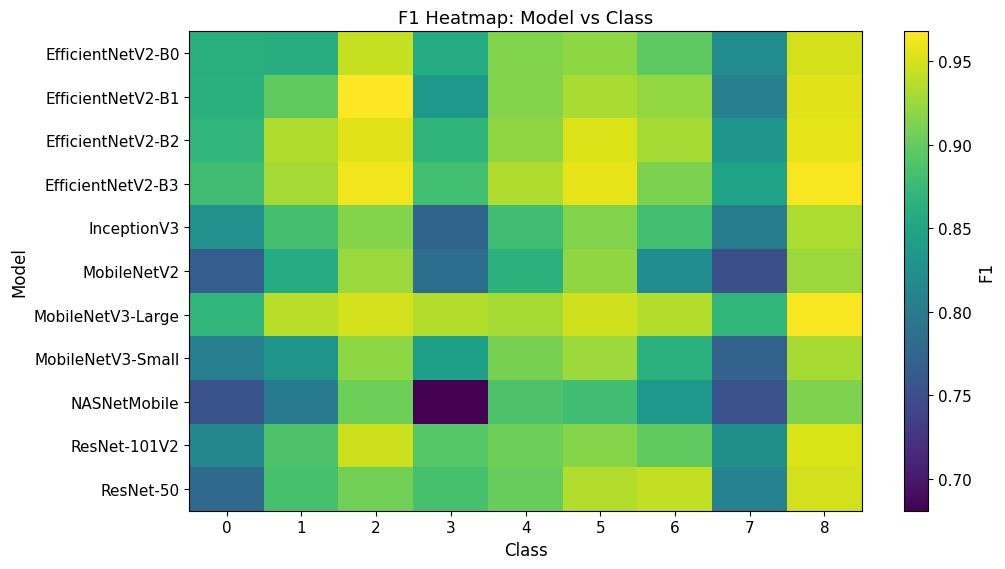

In [107]:
def plot_heatmap_f1_by_model_class(
    df_long,
    model_col="ModelDisplay",   # <<< usando nomes bonitos por padrão
    class_col="class",
    metric_col="metric",
    value_col="value",
    metric_name="f1",
    model_order=None,
    class_order=None,
    figsize=(10.5, 5.8),
    font_size=12,
    show_values=False,
    value_fmt="{:.2f}",
    vmin=None,
    vmax=None,
):
    d = df_long[df_long[metric_col] == metric_name].copy()

    mat = d.pivot_table(index=model_col, columns=class_col, values=value_col, aggfunc="mean")

    if class_order is not None:
        mat = mat.reindex(columns=class_order)
    else:
        mat = mat.sort_index(axis=1)

    if model_order is not None:
        mat = mat.reindex(index=model_order)

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        mat.values,
        aspect="auto",
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_xticks(np.arange(mat.shape[1]))
    ax.set_xticklabels([str(c) for c in mat.columns], fontsize=font_size - 1)
    ax.set_yticks(np.arange(mat.shape[0]))
    ax.set_yticklabels([str(m) for m in mat.index], fontsize=font_size - 1)

    ax.set_xlabel("Class", fontsize=font_size)
    ax.set_ylabel("Model", fontsize=font_size)
    ax.set_title("F1 Heatmap: Model vs Class", fontsize=font_size + 1)

    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.tick_params(labelsize=font_size - 1)
    cbar.set_label("F1", fontsize=font_size)

    if show_values:
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat.values[i, j]
                if np.isfinite(val):
                    ax.text(
                        j, i, value_fmt.format(val),
                        ha="center", va="center",
                        fontsize=font_size - 3
                    )

    plt.tight_layout()
    plt.savefig("Heatmapf1score(final).png", dpi=300, bbox_inches="tight")

    plt.show()
    
    

# Exemplo:
plot_heatmap_f1_by_model_class(long, show_values=False)

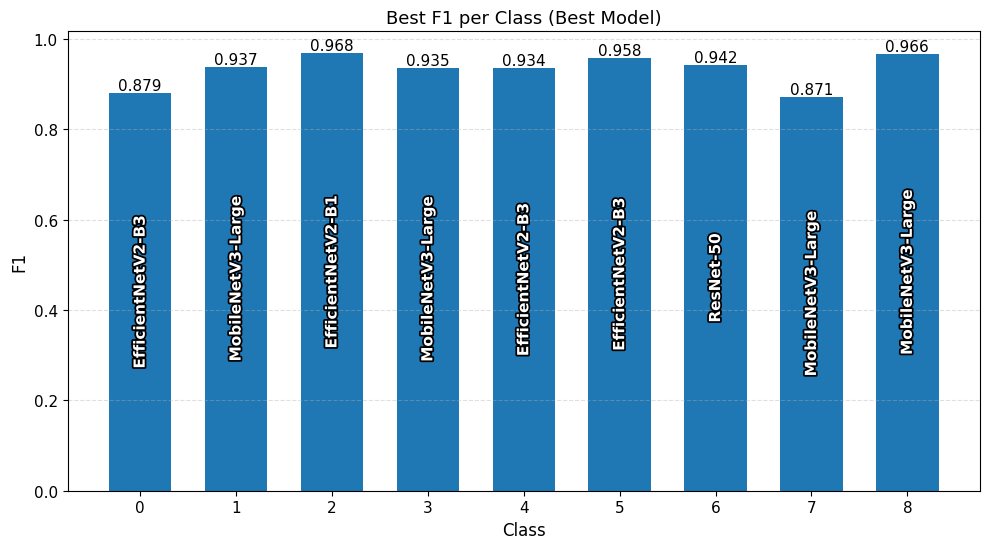

In [108]:
def plot_best_f1_by_class(
    df_long,
    class_col="class",
    model_col="ModelDisplay",   # usa nomes bonitos
    metric_col="metric",
    value_col="value",
    metric_name="f1",
    figsize=(10.0, 5.6),
    font_size=12,
    value_fmt="{:.3f}",
    order="class",              # "class" ou "desc"
    bar_width=0.65
):
    d = df_long[df_long[metric_col] == metric_name].copy()

    # melhor F1 por classe (pega o modelo correspondente)
    best = (
        d.sort_values(value_col, ascending=False)
         .groupby(class_col, as_index=False)
         .first()
         .rename(columns={value_col: "best_f1", model_col: "best_model"})
    )

    if order == "desc":
        best = best.sort_values("best_f1", ascending=False)
    else:
        best = best.sort_values(class_col, ascending=True)

    classes = best[class_col].astype(str).tolist()
    f1 = best["best_f1"].to_numpy()
    models = best["best_model"].astype(str).tolist()
    x = np.arange(len(classes))

    fig, ax = plt.subplots(figsize=figsize)

    bars = ax.bar(x, f1, width=bar_width)

    # 1) valor do F1 em cima da barra
    for bar, val in zip(bars, f1):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val,
            value_fmt.format(val),
            ha="center",
            va="bottom",
            fontsize=font_size - 1,
            clip_on=True
        )

    # 2) nome do modelo dentro da barra (vertical, branco, centralizado)
    for bar, m in zip(bars, models):
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h / 2,                 # centro da barra
            m,
            ha="center",
            va="center",
            rotation=90,
            fontsize=font_size - 1,
            fontweight="bold",
            color="white",
            path_effects=[pe.withStroke(linewidth=2.5, foreground="black")],
            clip_on=True
        )

    ax.set_title("Best F1 per Class (Best Model)", fontsize=font_size + 1)
    ax.set_xlabel("Class", fontsize=font_size)
    ax.set_ylabel("F1", fontsize=font_size)

    ax.set_xticks(x)
    ax.set_xticklabels(classes, fontsize=font_size - 1)
    ax.tick_params(axis="y", labelsize=font_size - 1)

    ax.grid(True, axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    
    plt.savefig("bestf1perclass(final).png", dpi=300, bbox_inches="tight")
    plt.show()
    
    


# Exemplo:
plot_best_f1_by_class(long, order="class")

In [110]:
pd.read_csv("/home/leo/Documentos/mestrado/DeepWeeds-Mobile/results_new/summary_results.csv")

,[Real] Latência Média (ms),[Real] FPS Média,Modelo,Acurácia Média,Precisão Média,Recall Médio,F1 Médio,weighted_precision,weighted_recall,weighted_f1,support_total,Parâmetros (M),GFLOPs,GMAC,Latência Média (ms),FPS Média
0,59.76,16.73,mobilenetv2,0.8812,0.8448,0.8539,0.8461,0.8860,0.8812,0.8818,2626,2.59,0.61,0.31,2.73,366.71
1,74.21,13.47,mobilenetv3large,0.9440,0.9270,0.9266,0.9263,0.9448,0.9440,0.9442,2626,3.24,0.44,0.22,2.66,375.52
2,63.71,15.70,mobilenetv3small,0.8964,0.8837,0.8547,0.8661,0.8974,0.8964,0.8951,2626,1.09,0.12,0.06,2.22,451.43
3,97.86,10.22,resnet50,0.9155,0.8948,0.8848,0.8877,0.9175,0.9155,0.9154,2626,24.11,7.75,3.88,5.98,167.34
4,181.40,5.51,resnet101v2,0.9193,0.8936,0.8933,0.8924,0.9202,0.9193,0.9192,2626,43.15,14.43,7.22,9.46,105.75
5,136.89,7.30,inceptionv3,0.8991,0.8900,0.8544,0.8673,0.9007,0.8991,0.8971,2626,22.33,11.47,5.73,7.74,129.22
6,281.26,3.56,nasnetmobile,0.8679,0.8529,0.8123,0.8232,0.8712,0.8679,0.8643,2626,4.54,1.15,0.57,9.62,104.00
7,140.57,7.11,efficientnetv2b0,0.9181,0.8910,0.8933,0.8911,0.9187,0.9181,0.9178,2626,6.25,1.46,0.73,3.37,296.96
8,172.26,5.81,efficientnetv2b1,0.9250,0.8997,0.9026,0.8990,0.9269,0.9250,0.9248,2626,7.26,2.42,1.21,4.16,240.62
9,178.35,5.61,efficientnetv2b2,0.9334,0.9079,0.9210,0.9133,0.9355,0.9334,0.9337,2626,9.13,3.44,1.72,4.67,214.26


In [125]:
long.loc[[long['model']=="mobilenetv2"]and [long['class']==0]] 

KeyError: "None of [Index([(True, True, True, True, True, True, True, True, True, True, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, ...)], dtype='object')] are in the [index]"